In [6]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
import time
from pynq import Overlay, allocate, MMIO

ol         = Overlay('audio.bit')
audio_mmio = MMIO(0x80000000, 0x10000)
dma_mmio   = MMIO(0x80010000, 0x10000)
print("Overlay loaded.")

Overlay loaded.


In [7]:
SAMPLE_SIZE = 1024
FRAME_SIZE  = 1024
HOP_SIZE    = 256

EN_PASSTHROUGH = 0b000
EN_VOL_ONLY    = 0b001
EN_ECHO_ONLY   = 0b010
EN_PITCH_ONLY  = 0b100
EN_ALL         = 0b111

FXP_SCALE = 256

def configure(en=EN_ALL, vol=1.0, delay=0.5, decay=0.5, tones=0):
    audio_mmio.write(0x10, en)
    audio_mmio.write(0x18, int(round(vol   * FXP_SCALE)) & 0xFFFFFFFF)
    audio_mmio.write(0x20, int(round(delay * FXP_SCALE)) & 0xFFFFFFFF)
    audio_mmio.write(0x28, int(round(decay * FXP_SCALE)) & 0xFFFFFFFF)
    audio_mmio.write(0x30, int(tones) & 0xFFFF)
    print(f"en={en:03b}  vol={vol}  delay={delay}  decay={decay}  tones={tones:+d}")

def dma_reset():
    dma_mmio.write(0x00, 0x04)
    dma_mmio.write(0x30, 0x04)
    time.sleep(0.05)
    dma_mmio.write(0x00, 0x01)
    dma_mmio.write(0x30, 0x01)

def process_block(input_int16):
    assert len(input_int16) == SAMPLE_SIZE
    assert input_int16.dtype == np.int16

    in_buf  = allocate(shape=(SAMPLE_SIZE,), dtype=np.int16)
    out_buf = allocate(shape=(SAMPLE_SIZE,), dtype=np.int16)
    np.copyto(in_buf, input_int16)
    nbytes = SAMPLE_SIZE * 2

    dma_reset()

    dma_mmio.write(0x48, out_buf.physical_address & 0xFFFFFFFF)
    dma_mmio.write(0x4C, (out_buf.physical_address >> 32) & 0xFFFFFFFF)
    dma_mmio.write(0x58, nbytes)
    audio_mmio.write(0x00, 0x01)
    dma_mmio.write(0x18, in_buf.physical_address & 0xFFFFFFFF)
    dma_mmio.write(0x1C, (in_buf.physical_address >> 32) & 0xFFFFFFFF)
    dma_mmio.write(0x28, nbytes)

    t0 = time.time()
    while not (dma_mmio.read(0x34) & 0x1000):
        if dma_mmio.read(0x34) & 0x70:
            raise RuntimeError(f"S2MM error: 0x{dma_mmio.read(0x34):08X}")
        if time.time() - t0 > 5.0:
            raise TimeoutError(
                f"Timeout MM2S=0x{dma_mmio.read(0x04):08X} "
                f"S2MM=0x{dma_mmio.read(0x34):08X}")

    result = np.array(out_buf, dtype=np.int16)
    in_buf.freebuffer()
    out_buf.freebuffer()
    return result

In [8]:
sr, wav_data = wavfile.read("input.wav")
print(f"{sr} Hz | {wav_data.dtype} | {len(wav_data)} samples ({len(wav_data)/sr:.2f} s)")

if wav_data.ndim == 2:
    wav_data = wav_data.mean(axis=1).astype(np.int16)
if wav_data.dtype != np.int16:
    wav_data = (wav_data * 32767).clip(-32768, 32767).astype(np.int16) \
               if np.issubdtype(wav_data.dtype, np.floating) \
               else wav_data.astype(np.int16)

pad = (-len(wav_data)) % SAMPLE_SIZE
if pad:
    wav_data = np.concatenate([wav_data, np.zeros(pad, dtype=np.int16)])
blocks = wav_data.reshape(-1, SAMPLE_SIZE)
print(f"{len(blocks)} blocks × {SAMPLE_SIZE} samples")

44100 Hz | int16 | 140928 samples (3.20 s)
138 blocks × 1024 samples


In [9]:
configure(en=EN_PASSTHROUGH)
out = process_block(blocks[0])
err = np.abs(blocks[0].astype(int) - out.astype(int)).max()
print(f"Passthrough max error: {err}  (expect 0)")

en=000  vol=1.0  delay=0.5  decay=0.5  tones=+0
Passthrough max error: 0  (expect 0)


In [10]:
configure(en=EN_VOL_ONLY, vol=0.5)
out_vol = process_block(blocks[0])
err = np.abs((blocks[0].astype(int) // 2) - out_vol.astype(int)).max()
print(f"Volume 0.5x max error: {err}  (expect near 0)")

en=001  vol=0.5  delay=0.5  decay=0.5  tones=+0
Volume 0.5x max error: 1  (expect near 0)


en=100  vol=1.0  delay=0.5  decay=0.5  tones=+1


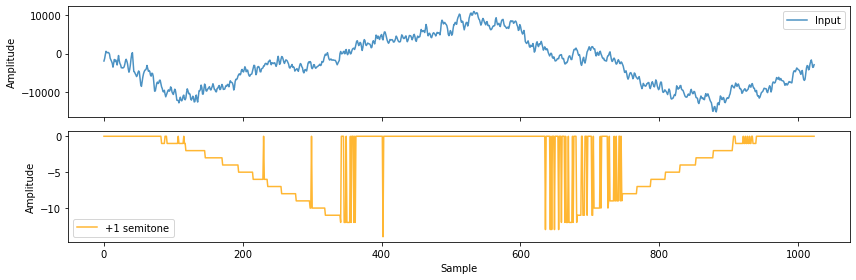

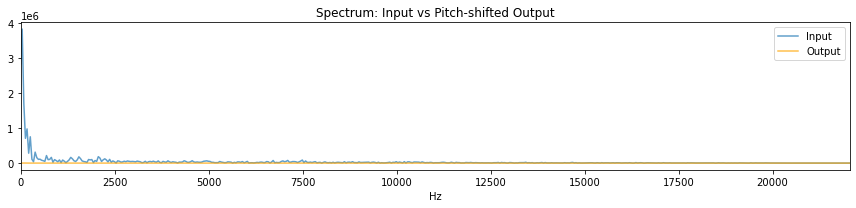

In [11]:
configure(en=EN_PITCH_ONLY, tones=1)
out_pitch = process_block(blocks[0])

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(blocks[0], alpha=0.8, label="Input")
axes[1].plot(out_pitch,  alpha=0.8, label="+1 semitone", color="orange")
for ax in axes:
    ax.set_ylabel("Amplitude"); ax.legend()
axes[1].set_xlabel("Sample")
plt.tight_layout(); plt.show()

f_ax = np.fft.rfftfreq(SAMPLE_SIZE, d=1/sr)
plt.figure(figsize=(12, 3))
plt.plot(f_ax, np.abs(np.fft.rfft(blocks[0].astype(float))), label="Input",  alpha=0.7)
plt.plot(f_ax, np.abs(np.fft.rfft(out_pitch.astype(float))), label="Output", alpha=0.7, color="orange")
plt.xlabel("Hz"); plt.xlim(0, sr//2); plt.legend()
plt.title("Spectrum: Input vs Pitch-shifted Output")
plt.tight_layout(); plt.show()

en=010  vol=1.0  delay=800  decay=0.5  tones=+0
Impulse[0]       = 10000  (expect 10000)
Echo tap [800] = 5000  (expect ~5000)
en=010  vol=1.0  delay=800  decay=0.5  tones=+0


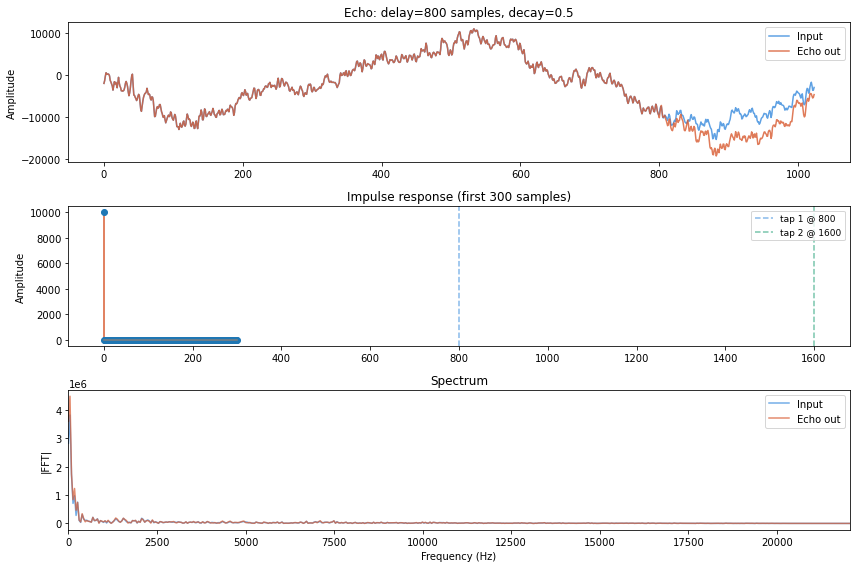

en=010  vol=1.0  delay=800  decay=0.0  tones=+0
decay=0 passthrough max error: 0  (expect 0 or near-0)


In [12]:
DELAY_SAMPLES = 800
DECAY_VAL     = 0.5

impulse = np.zeros(SAMPLE_SIZE, dtype=np.int16)
impulse[0] = 10000

configure(en=EN_ECHO_ONLY, delay=DELAY_SAMPLES, decay=DECAY_VAL)
out_impulse = process_block(impulse)
print(f"Impulse[0]       = {out_impulse[0]}  (expect 10000)")
print(f"Echo tap [{DELAY_SAMPLES}] = {out_impulse[DELAY_SAMPLES]}  (expect ~{int(10000*DECAY_VAL)})")

configure(en=EN_ECHO_ONLY, delay=DELAY_SAMPLES, decay=DECAY_VAL)
out_echo = process_block(blocks[0])

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(blocks[0], alpha=0.8, label="Input",    color="#378ADD")
axes[0].plot(out_echo,  alpha=0.8, label="Echo out", color="#D85A30")
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f"Echo: delay={DELAY_SAMPLES} samples, decay={DECAY_VAL}")
axes[0].legend()

axes[1].stem(range(min(300, SAMPLE_SIZE)), out_impulse[:300],
             linefmt="#D85A30", markerfmt="o", basefmt="gray")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Impulse response (first 300 samples)")
axes[1].axvline(DELAY_SAMPLES,   color="#378ADD", linestyle="--", alpha=0.6, label=f"tap 1 @ {DELAY_SAMPLES}")
axes[1].axvline(DELAY_SAMPLES*2, color="#1D9E75", linestyle="--", alpha=0.6, label=f"tap 2 @ {DELAY_SAMPLES*2}")
axes[1].legend(fontsize=9)

f_ax = np.fft.rfftfreq(SAMPLE_SIZE, d=1/sr)
axes[2].plot(f_ax, np.abs(np.fft.rfft(blocks[0].astype(float))), alpha=0.7, label="Input",    color="#378ADD")
axes[2].plot(f_ax, np.abs(np.fft.rfft(out_echo.astype(float))),  alpha=0.7, label="Echo out", color="#D85A30")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("|FFT|")
axes[2].set_xlim(0, sr//2)
axes[2].set_title("Spectrum")
axes[2].legend()
plt.tight_layout(); plt.show()

configure(en=EN_ECHO_ONLY, delay=DELAY_SAMPLES, decay=0.0)
out_nodecay = process_block(blocks[0])
err = np.abs(blocks[0].astype(int) - out_nodecay.astype(int)).max()
print(f"decay=0 passthrough max error: {err}  (expect 0 or near-0)")

In [13]:
configure(en=EN_PITCH_ONLY, tones=1)

out_blocks = np.zeros_like(blocks)
t0 = time.time()
for i, blk in enumerate(blocks):
    out_blocks[i] = process_block(blk)
    if i % 20 == 0:
        print(f"  {i+1}/{len(blocks)}  ({time.time()-t0:.1f}s)")

wavfile.write("output.wav", sr, out_blocks.flatten().astype(np.int16))
print(f"Done in {time.time()-t0:.1f}s  →  output.wav")

en=100  vol=1.0  delay=0.5  decay=0.5  tones=+1
  1/138  (0.1s)
  21/138  (1.1s)
  41/138  (2.1s)
  61/138  (3.2s)
  81/138  (4.2s)
  101/138  (5.2s)
  121/138  (6.3s)
Done in 7.1s  →  output.wav
